In [28]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Data Import.

In [8]:
DATA_PATH = "../Data/winequality-red.csv"

df = pd.read_csv(DATA_PATH)

df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
X = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']]
Y = df[['quality']]

In [12]:
x_train_len = int(0.7 * len(df))
X_train = X.iloc[:x_train_len]
Y_train = Y.iloc[:x_train_len]

x_test_len = int(0.2 * len(df))
X_test = X.iloc[x_train_len: (x_train_len + x_test_len)]
Y_test = Y.iloc[x_train_len: (x_train_len + x_test_len)]

X_validate = X.iloc[x_train_len + x_test_len:]
Y_validate = Y.iloc[x_train_len + x_test_len:]

In [13]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32)

X_validate_tensor = torch.tensor(X_validate.values, dtype=torch.float32)
Y_validate_tensor = torch.tensor(Y_validate.values, dtype=torch.float32)

In [17]:
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
validate_dataset = TensorDataset(X_validate_tensor, Y_validate_tensor)

In [19]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

validate_loader = DataLoader(
    validate_dataset,
    batch_size=batch_size,
    shuffle=False
)

Code.
Using only Linear Layers of the torch.nn.
1. nn.Linear
2. nn.LazyLinear

In [40]:
'''
For nn.Linear
device is cpu, i dont have CUDA.
dtype is flote32 default

2 dense Layers.
'''

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(
            in_features=11,
            out_features=5,
            bias=True,
        )
        self.layer2 = nn.Linear(
            in_features=5,
            out_features=3,
            bias=True,
        )
        self.layer3 = nn.Linear(
            in_features=3,
            out_features=1,
            bias=True
        )

    def forward(self, input):
        x = self.layer1(input)
        x = torch.relu(x)

        x = self.layer2(x)
        x = torch.relu(x)

        x = self.layer3(x)
        x = torch.relu(x)

        return x



In [41]:
# Training sequence
loss_history = []

torch.manual_seed(42)
model = LinearModel()

loss_fun = nn.MSELoss()

learning_rate = 0.0001
optimiser = optim.SGD(
    model.parameters(),
    lr=learning_rate
)

epochs = 1000
for epoch in range(epochs):
    model.train()

    for i, (inputs, targets) in enumerate(train_loader):
        output = model(inputs)
        
        loss = loss_fun(output, targets)
        optimiser.zero_grad()

        loss.backward()

        optimiser.step()
        loss_history.append(loss.item())




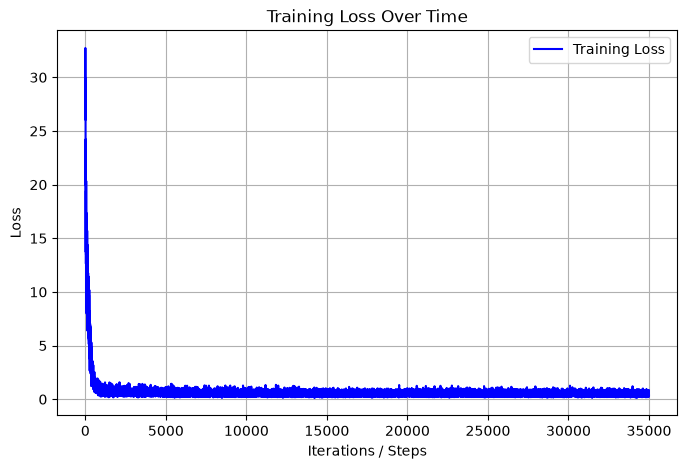

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Training Loss', color='blue')
plt.xlabel('Iterations / Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Testing sequence